# 03 · Deep Learning with PyTorch

> 🇪🇸 Versión en español: [`03_pytorch.ipynb`](03_pytorch.ipynb)

PyTorch gives you three fundamental pieces:

1. **Tensors**: like NumPy arrays, but they can live on a GPU.
2. **Autograd**: computes gradients automatically (backpropagation).
3. **`torch.nn` + `torch.optim`**: layers, loss functions and optimizers.

Unlike scikit-learn, **you write the training loop yourself**. At the end we solve the same
house-price problem and compare with notebook 02.

In [1]:
# Libraries
#=====================================================
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)

torch 2.14.0+cu130 | device: cpu


## 1. Tensors

In [2]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.ones(2, 2)

print(a + b)            # element-wise
print(a @ b)            # matrix product
print(a.shape, a.dtype)
print(a.numpy())        # to NumPy (shares memory on CPU)
print(torch.from_numpy(np.arange(3)))

tensor([[2., 3.],
        [4., 5.]])


tensor([[3., 3.],
        [7., 7.]])
torch.Size([2, 2]) torch.float32
[[1. 2.]
 [3. 4.]]
tensor([0, 1, 2])


## 2. Autograd

If a tensor has `requires_grad=True`, PyTorch records the operations and `backward()` computes derivatives.
For $y = x^2 + 3x$, the derivative at $x=2$ is $2x + 3 = 7$.

In [3]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3 * x
y.backward()
print(x.grad)

tensor(7.)


## 3. Linear regression "by hand" with autograd

Gradient descent on synthetic data $y = 3x + 2 + \\text{noise}$. This is what you did *from scratch*
in `03_ml_from_scratch`, but without deriving the gradients by hand.

In [4]:
X_toy = torch.linspace(-1, 1, 100).unsqueeze(1)
y_toy = 3 * X_toy + 2 + 0.2 * torch.randn_like(X_toy)

w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.1

for epoch in range(200):
    pred = X_toy * w + b
    loss = ((pred - y_toy) ** 2).mean()
    loss.backward()             # computes dL/dw and dL/db
    with torch.no_grad():       # update without recording in the graph
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_(); b.grad.zero_()

print(f"w = {w.item():.3f} (true 3), b = {b.item():.3f} (true 2)")

w = 2.994 (true 3), b = 2.012 (true 2)


## 4. Neural network to predict prices

### 4.1 Prepare the data
We reuse the scikit-learn preprocessor: combining both libraries is very common.
The target is scaled too; networks train much better with values of order 1.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pl.read_csv("datos/houses.csv")
X = df.drop("id", "price")
y = df["price"].to_numpy().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]),
     ["sqm", "rooms", "age", "distance_center_km"]),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["neighborhood", "has_garage"]),
])
y_scaler = StandardScaler()

def to_tensor(arr):
    return torch.tensor(np.asarray(arr), dtype=torch.float32)

Xtr = to_tensor(prep.fit_transform(X_train)); ytr = to_tensor(y_scaler.fit_transform(y_train))
Xva = to_tensor(prep.transform(X_val));       yva = to_tensor(y_scaler.transform(y_val))
Xte = to_tensor(prep.transform(X_test))

loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
print(Xtr.shape, Xva.shape, Xte.shape)

torch.Size([1280, 10]) torch.Size([320, 10]) torch.Size([400, 10])


### 4.2 Define the model
A multilayer perceptron (MLP): `Linear → ReLU → Linear → ReLU → Linear`.

In [6]:
class PriceNet(nn.Module):
    def __init__(self, n_inputs, hidden=64):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.layers(x)

model = PriceNet(Xtr.shape[1]).to(device)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

PriceNet(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 4929


### 4.3 Training loop
The 5 steps you will repeat in every PyTorch project:
`zero_grad` → `forward` → `loss` → `backward` → `step`.
We keep the best model according to the validation loss (simple *early stopping*).

Early stopping at epoch 54


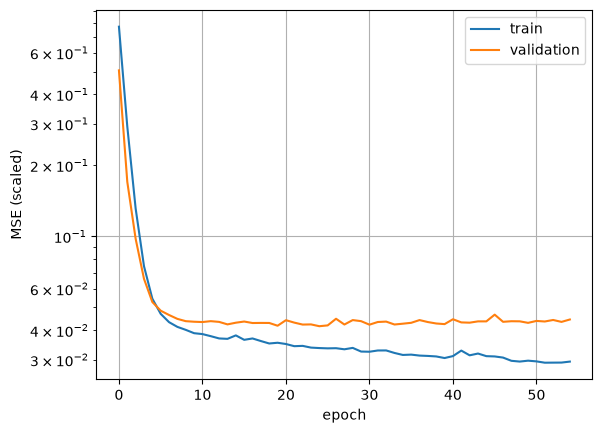

In [7]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = {"train": [], "val": []}
best_val, best_state, patience, no_improve = float("inf"), None, 30, 0

for epoch in range(500):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    history["train"].append(total / len(loader.dataset))

    model.eval()
    with torch.no_grad():
        val = loss_fn(model(Xva.to(device)), yva.to(device)).item()
    history["val"].append(val)

    if val < best_val:
        best_val, no_improve = val, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
plt.plot(history["train"], label="train"); plt.plot(history["val"], label="validation")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled)"); plt.legend(); plt.grid(True)
plt.show()

### 4.4 Evaluate on test and compare with scikit-learn

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

model.eval()
with torch.no_grad():
    pred = y_scaler.inverse_transform(model(Xte.to(device)).cpu().numpy())

print(f"MAE : {mean_absolute_error(y_test, pred):,.0f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred):,.0f}")
print(f"R²  : {r2_score(y_test, pred):.3f}")

MAE : 14,742
RMSE: 19,290
R²  : 0.964


> Compare with the Gradient Boosting model from notebook 02. On **small tabular datasets**, tree-based models
> usually match or beat neural networks with far less effort. PyTorch shines with images, text, audio,
> time series, or when you need custom architectures (e.g. physics-informed neural networks).

### Save the model
Save the `state_dict` (the weights), not the whole object.

In [9]:
torch.save(model.state_dict(), "price_net.pt")
new_model = PriceNet(Xtr.shape[1])
new_model.load_state_dict(torch.load("price_net.pt", weights_only=True))
new_model.eval();

## Summary
| Concept | Scikit-learn | PyTorch |
|---|---|---|
| Training | `model.fit(X, y)` | manual loop: `zero_grad/forward/loss/backward/step` |
| Data | NumPy / Pandas / Polars | `torch.Tensor` + `DataLoader` |
| Models | ready-made catalog | you build them with `nn.Module` |
| Best for | tabular data, classic models | deep learning, GPU, custom architectures |

## ✏️ Exercises
1. Change the hidden layer size (16, 128) and add `nn.Dropout(0.1)`. Does validation improve?
2. Replace `Adam` with `SGD(lr=0.01, momentum=0.9)` and compare the loss curves.
3. Turn the network into a **classifier** (expensive / cheap house): last layer with 1 output + `nn.BCEWithLogitsLoss`.
4. Rewrite section 3 to fit a degree-3 polynomial with autograd.